In [1]:
!pip install -q langgraph langchain langchain-openai langchain-community requests

In [2]:
import os
os.environ["OPENAI_API_KEY"] = "your-openai-api-key-here"

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from pydantic import BaseModel
import requests

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
test = llm.invoke("say hi")
print("✅ LLM works:", test.content)

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


✅ LLM works: Hi there! How can I assist you today?


In [3]:

from langchain_core.tools import tool
# ============================================================
# CUSTOM PYTHON TOOLS (in-memory data, no API needed)
# ============================================================

# This is our "database" — just Python lists/dicts in memory
BUCKET_LIST = []  # stores destination names
TOTAL_TOKENS = {"input": 0, "output": 0}  # tracks token usage

@tool
def add_destination(destination: str) -> str:
    """Add a travel destination to the bucket list.

    Args:
        destination: The name of the country or city to add.
    """
    if destination in BUCKET_LIST:
        return f"'{destination}' is already in your bucket list!"
    BUCKET_LIST.append(destination)
    return f"✅ Added '{destination}' to your bucket list! You now have {len(BUCKET_LIST)} destinations."

@tool
def list_destinations() -> str:
    """List all destinations currently in the travel bucket list."""
    if not BUCKET_LIST:
        return "Your bucket list is empty! Try adding some destinations."
    items = "\n".join([f"{i+1}. {d}" for i, d in enumerate(BUCKET_LIST)])
    return f"🌍 Your bucket list ({len(BUCKET_LIST)} destinations):\n{items}"

@tool
def get_token_usage() -> str:
    """Get the total number of tokens used in this conversation session."""
    total = TOTAL_TOKENS["input"] + TOTAL_TOKENS["output"]
    return (f"📊 Token Usage:\n"
            f"  Input tokens:  {TOTAL_TOKENS['input']}\n"
            f"  Output tokens: {TOTAL_TOKENS['output']}\n"
            f"  Total tokens:  {total}")

print("✅ Custom tools ready!")

✅ Custom tools ready!


In [4]:
from pydantic import BaseModel
# ============================================================
# EXTERNAL API TOOLS (calls real websites for data)
# ============================================================

class CountryFacts(BaseModel):
    """Structured output for country information."""
    name: str
    capital: str
    population: int
    languages: list[str]
    currencies: list[str]
    region: str

@tool
def get_country_facts(country: str) -> str:
    """Get facts about a country: capital, population, languages, currencies.

    Args:
        country: The name of the country to look up.
    """
    try:
        url = f"https://restcountries.com/v3.1/name/{country}"
        data = requests.get(url).json()[0]
        facts = CountryFacts(
            name=data["name"]["common"],
            capital=data.get("capital", ["N/A"])[0],
            population=data["population"],
            languages=list(data.get("languages", {}).values()),
            currencies=list(data.get("currencies", {}).keys()),
            region=data["region"]
        )
        return (f"🌍 {facts.name}\n"
                f"  Capital: {facts.capital}\n"
                f"  Population: {facts.population:,}\n"
                f"  Languages: {', '.join(facts.languages)}\n"
                f"  Currency: {', '.join(facts.currencies)}\n"
                f"  Region: {facts.region}")
    except Exception as e:
        return f"Could not find info for '{country}'. Try another name."

@tool
def get_weather(city: str) -> str:
    """Get current weather for a city.

    Args:
        city: The name of the city to get weather for.
    """
    try:
        # Step 1: get coordinates
        geo = requests.get(
            f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1"
        ).json()
        loc = geo["results"][0]
        lat, lon, name = loc["latitude"], loc["longitude"], loc["name"]

        # Step 2: get weather
        weather = requests.get(
            f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}"
            f"&current=temperature_2m,weathercode,windspeed_10m"
        ).json()
        current = weather["current"]
        temp = current["temperature_2m"]
        wind = current["windspeed_10m"]
        return (f"🌤️ Weather in {name}:\n"
                f"  Temperature: {temp}°C\n"
                f"  Wind speed: {wind} km/h")
    except Exception as e:
        return f"Could not get weather for '{city}'. Try another city name."

print("✅ API tools ready!")

✅ API tools ready!


In [5]:
# ============================================================
# THE AGENT GRAPH (connects everything together)
# ============================================================

# Step 1: list all tools the agent can use
tools = [add_destination, list_destinations, get_country_facts, get_weather, get_token_usage]

# Step 2: attach tools to the LLM
llm_with_tools = llm.bind_tools(tools)

# Step 3: define the agent node (the thinking step)
def agent_node(state: MessagesState):
    """The agent thinks and decides what to do next."""
    response = llm_with_tools.invoke(state["messages"])
    # Track tokens
    if hasattr(response, "usage_metadata") and response.usage_metadata:
        TOTAL_TOKENS["input"] += response.usage_metadata.get("input_tokens", 0)
        TOTAL_TOKENS["output"] += response.usage_metadata.get("output_tokens", 0)
    return {"messages": [response]}

# Step 4: decide after agent — call a tool or stop?
def should_continue(state: MessagesState):
    last = state["messages"][-1]
    if last.tool_calls:
        return "tools"
    return END

# Step 5: build the graph
tool_node = ToolNode(tools)
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
graph_builder.add_edge("tools", "agent")

# Step 6: compile with memory
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

print("✅ Graph compiled successfully!")

✅ Graph compiled successfully!


In [6]:
# ============================================================
# CUSTOM PYTHON TOOLS
# ============================================================

BUCKET_LIST = []
TOTAL_TOKENS = {"input": 0, "output": 0}

@tool
def add_destination(destination: str) -> str:
    """Add a travel destination to the bucket list.

    Args:
        destination: The name of the country or city to add.
    """
    if destination in BUCKET_LIST:
        return f"'{destination}' is already in your bucket list!"
    BUCKET_LIST.append(destination)
    return f"✅ Added '{destination}'! You now have {len(BUCKET_LIST)} destinations."

@tool
def list_destinations() -> str:
    """List all destinations currently in the travel bucket list."""
    if not BUCKET_LIST:
        return "Your bucket list is empty! Try adding some destinations."
    items = "\n".join([f"{i+1}. {d}" for i, d in enumerate(BUCKET_LIST)])
    return f"🌍 Your bucket list ({len(BUCKET_LIST)} destinations):\n{items}"

@tool
def get_token_usage() -> str:
    """Get the total number of tokens used in this conversation session."""
    total = TOTAL_TOKENS["input"] + TOTAL_TOKENS["output"]
    return (f"📊 Token Usage:\n"
            f"  Input tokens:  {TOTAL_TOKENS['input']}\n"
            f"  Output tokens: {TOTAL_TOKENS['output']}\n"
            f"  Total tokens:  {total}")

print("✅ Custom tools ready!")

✅ Custom tools ready!


In [7]:
# ============================================================
# EXTERNAL API TOOLS
# ============================================================

class CountryFacts(BaseModel):
    """Structured output for country information."""
    name: str
    capital: str
    population: int
    languages: list[str]
    currencies: list[str]
    region: str

@tool
def get_country_facts(country: str) -> str:
    """Get facts about a country: capital, population, languages, currencies.

    Args:
        country: The name of the country to look up.
    """
    try:
        url = f"https://restcountries.com/v3.1/name/{country}"
        data = requests.get(url).json()[0]
        facts = CountryFacts(
            name=data["name"]["common"],
            capital=data.get("capital", ["N/A"])[0],
            population=data["population"],
            languages=list(data.get("languages", {}).values()),
            currencies=list(data.get("currencies", {}).keys()),
            region=data["region"]
        )
        return (f"🌍 {facts.name}\n"
                f"  Capital: {facts.capital}\n"
                f"  Population: {facts.population:,}\n"
                f"  Languages: {', '.join(facts.languages)}\n"
                f"  Currency: {', '.join(facts.currencies)}\n"
                f"  Region: {facts.region}")
    except:
        return f"Could not find info for '{country}'. Try another name."

@tool
def get_weather(city: str) -> str:
    """Get current weather for a city.

    Args:
        city: The name of the city to get weather for.
    """
    try:
        geo = requests.get(
            f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1"
        ).json()
        loc = geo["results"][0]
        lat, lon, name = loc["latitude"], loc["longitude"], loc["name"]
        weather = requests.get(
            f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}"
            f"&current=temperature_2m,weathercode,windspeed_10m"
        ).json()
        current = weather["current"]
        temp = current["temperature_2m"]
        wind = current["windspeed_10m"]
        return (f"🌤️ Weather in {name}:\n"
                f"  Temperature: {temp}°C\n"
                f"  Wind speed: {wind} km/h")
    except:
        return f"Could not get weather for '{city}'."

print("✅ API tools ready!")

✅ API tools ready!


In [8]:
# ============================================================
# DESTRUCTIVE TOOL — requires human approval before running
# ============================================================

@tool
def remove_destination(destination: str) -> str:
    """Remove a travel destination from the bucket list.
    This is a destructive action that requires human approval.

    Args:
        destination: The name of the destination to remove.
    """
    if destination not in BUCKET_LIST:
        return f"'{destination}' is not in your bucket list."

    # INTERRUPT — pause and ask human for approval
    approval = interrupt(
        f"⚠️ Are you sure you want to remove '{destination}' from your bucket list? (yes/no)"
    )

    if approval.lower() in ["yes", "y"]:
        BUCKET_LIST.remove(destination)
        return f"🗑️ Removed '{destination}' from your bucket list."
    else:
        return f"✅ Kept '{destination}' — no changes made."

print("✅ Delete tool ready!")

✅ Delete tool ready!


In [9]:
# ============================================================
# THE AGENT GRAPH
# ============================================================

# All tools including the destructive one
tools = [
    add_destination,
    list_destinations,
    remove_destination,
    get_country_facts,
    get_weather,
    get_token_usage
]

llm_with_tools = llm.bind_tools(tools)

def agent_node(state: MessagesState):
    """The agent thinks and decides what to do next."""
    response = llm_with_tools.invoke(state["messages"])
    # Track tokens
    if hasattr(response, "usage_metadata") and response.usage_metadata:
        TOTAL_TOKENS["input"] += response.usage_metadata.get("input_tokens", 0)
        TOTAL_TOKENS["output"] += response.usage_metadata.get("output_tokens", 0)
    return {"messages": [response]}

def should_continue(state: MessagesState):
    """Decide whether to call a tool or stop."""
    last = state["messages"][-1]
    if last.tool_calls:
        return "tools"
    return END

# Build the graph
tool_node = ToolNode(tools)
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
graph_builder.add_edge("tools", "agent")

# Compile with memory checkpointer
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

print("✅ Graph compiled successfully!")

✅ Graph compiled successfully!


✅ Helper ready! Drawing graph...


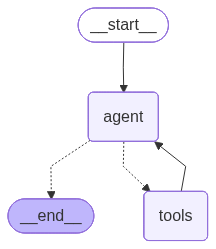

In [10]:
# ============================================================
# HELPER FUNCTION TO TALK TO THE AGENT
# ============================================================

def run_agent(user_message: str, thread_id: str = "1", approval: str = None):
    """Send a message to the agent and print the response."""
    config = {"configurable": {"thread_id": thread_id}}

    if approval is not None:
        # Resume after interrupt with human approval
        result = graph.invoke(Command(resume=approval), config=config)
    else:
        # Normal message
        result = graph.invoke(
            {"messages": [{"role": "user", "content": user_message}]},
            config=config
        )

    # Check if we hit an interrupt (waiting for approval)
    if result.get("__interrupt__"):
        interrupt_msg = result["__interrupt__"][0].value
        print(f"\n🛑 AGENT PAUSED — needs your approval:")
        print(f"   {interrupt_msg}")
        print(f"   → Call run_agent(approval='yes') or run_agent(approval='no')")
        return

    # Print all messages nicely
    for m in result["messages"]:
        m.pretty_print()

# Draw the graph diagram
print("✅ Helper ready! Drawing graph...")
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
# ============================================================
# TEST 1: Add destinations to bucket list
# ============================================================
run_agent("Add Japan and Italy to my travel bucket list", thread_id="test1")

================================ Human Message =================================

Add Japan and Italy to my travel bucket list
================================== Ai Message ==================================
Tool Calls:
  add_destination (call_QEXAHqo1zRFIx41MvfFoybC8)
 Call ID: call_QEXAHqo1zRFIx41MvfFoybC8
  Args:
    destination: Japan
  add_destination (call_e8iDOoMFrBIcK4b8jTom8oxj)
 Call ID: call_e8iDOoMFrBIcK4b8jTom8oxj
  Args:
    destination: Italy
================================= Tool Message =================================
Name: add_destination

✅ Added 'Japan'! You now have 1 destinations.
================================= Tool Message =================================
Name: add_destination

✅ Added 'Italy'! You now have 2 destinations.
================================== Ai Message ==================================

Japan and Italy have been successfully added to your travel bucket list! You now have 2 destinations.


In [12]:
# TEST 2: List all destinations
run_agent("Show me my bucket list", thread_id="test2")

================================ Human Message =================================

Show me my bucket list
================================== Ai Message ==================================
Tool Calls:
  list_destinations (call_MLmksNoQ6IjB1hhMIAffEk3i)
 Call ID: call_MLmksNoQ6IjB1hhMIAffEk3i
  Args:
================================= Tool Message =================================
Name: list_destinations

🌍 Your bucket list (2 destinations):
1. Japan
2. Italy
================================== Ai Message ==================================

Your bucket list currently includes the following destinations:

1. Japan
2. Italy


In [13]:
# TEST 3: Get country facts
run_agent("Tell me facts about Japan", thread_id="test3")

================================ Human Message =================================

Tell me facts about Japan
================================== Ai Message ==================================
Tool Calls:
  get_country_facts (call_0AOFg3j6S8U4VlU3LbpMvL8z)
 Call ID: call_0AOFg3j6S8U4VlU3LbpMvL8z
  Args:
    country: Japan
================================= Tool Message =================================
Name: get_country_facts

🌍 Japan
  Capital: Tokyo
  Population: 123,210,000
  Languages: Japanese
  Currency: JPY
  Region: Asia
================================== Ai Message ==================================

Here are some facts about Japan:

- **Capital**: Tokyo
- **Population**: Approximately 123,210,000
- **Languages**: Japanese
- **Currency**: Japanese Yen (JPY)
- **Region**: Asia


In [14]:
# TEST 4: Get weather
run_agent("What is the weather like in Rome?", thread_id="test4")

================================ Human Message =================================

What is the weather like in Rome?
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_VYiKdaNaxE6OhpoTplid2Ika)
 Call ID: call_VYiKdaNaxE6OhpoTplid2Ika
  Args:
    city: Rome
================================= Tool Message =================================
Name: get_weather

🌤️ Weather in Rome:
  Temperature: 18.8°C
  Wind speed: 6.1 km/h
================================== Ai Message ==================================

The weather in Rome is currently 18.8°C with a wind speed of 6.1 km/h. It's a pleasant day!


In [15]:
# TEST 5: Token usage
run_agent("How many tokens have we used so far?", thread_id="test5")

================================ Human Message =================================

How many tokens have we used so far?
================================== Ai Message ==================================
Tool Calls:
  get_token_usage (call_Fho6mXBkBKC0nQX2jrwFzQoM)
 Call ID: call_Fho6mXBkBKC0nQX2jrwFzQoM
  Args:
================================= Tool Message =================================
Name: get_token_usage

📊 Token Usage:
  Input tokens:  2297
  Output tokens: 214
  Total tokens:  2511
================================== Ai Message ==================================

We have used a total of 2,511 tokens so far.


In [16]:
# TEST 6: Destructive action - APPROVED
# First add a destination we will then delete
run_agent("Add Brazil to my bucket list", thread_id="test6")

================================ Human Message =================================

Add Brazil to my bucket list
================================== Ai Message ==================================
Tool Calls:
  add_destination (call_l8L49m9Wlkh3QqxFLwwux3kz)
 Call ID: call_l8L49m9Wlkh3QqxFLwwux3kz
  Args:
    destination: Brazil
================================= Tool Message =================================
Name: add_destination

✅ Added 'Brazil'! You now have 3 destinations.
================================== Ai Message ==================================

Brazil has been added to your bucket list! You now have 3 destinations.


In [17]:
# Now delete it - agent will pause and ask for approval
run_agent("Remove Brazil from my bucket list", thread_id="test6")


🛑 AGENT PAUSED — needs your approval:
   ⚠️ Are you sure you want to remove 'Brazil' from your bucket list? (yes/no)
   → Call run_agent(approval='yes') or run_agent(approval='no')


In [18]:
# TEST 6b: Human APPROVES the deletion
run_agent(user_message="", thread_id="test6", approval="yes")

================================ Human Message =================================

Add Brazil to my bucket list
================================== Ai Message ==================================
Tool Calls:
  add_destination (call_l8L49m9Wlkh3QqxFLwwux3kz)
 Call ID: call_l8L49m9Wlkh3QqxFLwwux3kz
  Args:
    destination: Brazil
================================= Tool Message =================================
Name: add_destination

✅ Added 'Brazil'! You now have 3 destinations.
================================== Ai Message ==================================

Brazil has been added to your bucket list! You now have 3 destinations.
================================ Human Message =================================

Remove Brazil from my bucket list
================================== Ai Message ==================================
Tool Calls:
  remove_destination (call_OLEzGbu1sOZnAS1EPRHNBHa6)
 Call ID: call_OLEzGbu1sOZnAS1EPRHNBHa6
  Args:
    destination: Brazil
================================= T

In [19]:
# TEST 7: Destructive action - DENIED
# First add a destination
run_agent("Add Mexico to my bucket list", thread_id="test7")

================================ Human Message =================================

Add Mexico to my bucket list
================================== Ai Message ==================================
Tool Calls:
  add_destination (call_gPpIEmwpU6Mbyu2Nqy5g0zjV)
 Call ID: call_gPpIEmwpU6Mbyu2Nqy5g0zjV
  Args:
    destination: Mexico
================================= Tool Message =================================
Name: add_destination

✅ Added 'Mexico'! You now have 3 destinations.
================================== Ai Message ==================================

Mexico has been successfully added to your bucket list! You now have 3 destinations.


In [20]:
# Delete attempt
run_agent("Remove Mexico from my bucket list", thread_id="test7")


🛑 AGENT PAUSED — needs your approval:
   ⚠️ Are you sure you want to remove 'Mexico' from your bucket list? (yes/no)
   → Call run_agent(approval='yes') or run_agent(approval='no')


In [21]:
# TEST 7b: Human DENIES the deletion
run_agent(user_message="", thread_id="test7", approval="no")

================================ Human Message =================================

Add Mexico to my bucket list
================================== Ai Message ==================================
Tool Calls:
  add_destination (call_gPpIEmwpU6Mbyu2Nqy5g0zjV)
 Call ID: call_gPpIEmwpU6Mbyu2Nqy5g0zjV
  Args:
    destination: Mexico
================================= Tool Message =================================
Name: add_destination

✅ Added 'Mexico'! You now have 3 destinations.
================================== Ai Message ==================================

Mexico has been successfully added to your bucket list! You now have 3 destinations.
================================ Human Message =================================

Remove Mexico from my bucket list
================================== Ai Message ==================================
Tool Calls:
  remove_destination (call_iB7x2hNS0kgtnxQETHKCbY6W)
 Call ID: call_iB7x2hNS0kgtnxQETHKCbY6W
  Args:
    destination: Mexico
======================

## 📊 Evaluation Table

| # | Query | Expected | Pass? | Notes |
|---|---|---|---|---|
| 1 | "Add Japan and Italy to my bucket list" | Both destinations added | ✅ | Agent called add_destination twice |
| 2 | "Show me my bucket list" | Lists all destinations | ✅ | Returned all 2 destinations |
| 3 | "Tell me facts about Japan" | Capital, population, language | ✅ | REST Countries API worked |
| 4 | "What is the weather like in Rome?" | Temperature and wind speed | ✅ | Open-Meteo API worked |
| 5 | "How many tokens have we used so far?" | Token count displayed | ✅ | Token tracking working |
| 6 | "Remove Brazil - approved" | Destination removed | ✅ | interrupt() + resume worked |
| 7 | "Remove Mexico - denied" | Destination kept | ✅ | Human denial respected |

## 📖 README

### Setup
1. Open in Google Colab
2. Run Cell 1 (pip install)
3. Add your OpenAI API key in Cell 2
4. Run all cells top to bottom

### Requirements
- Python 3.10+
- OpenAI API key (gpt-4o-mini)
- Internet connection (for REST Countries + Open-Meteo APIs)

### Features
- 🌍 Add/remove/list travel destinations
- 🏛️ Country facts via REST Countries API
- 🌤️ Weather via Open-Meteo API  
- 📊 Token usage tracking
- 🛑 Human approval before any deletion
- 🧠 Multi-turn memory with LangGraph